# DBSCAN 

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed (high density) and marks as outliers the points that lie alone in low-density regions.


<br>

<p align="center">
<img src="visualizations/dbscan.gif" width="600">
</p>


## 🌟 How DBSCAN Works (Step by Step)

1. **Pick a starting point** that hasn’t been visited yet.
2. **Look around** it to see how many points are nearby (within a certain distance ε).
3. If there are **enough nearby points** (at least MinPts), we say it's in a dense area and start building a **cluster**:

   * Add the starting point and all nearby points to the cluster.
   * Then repeat this process for each of those nearby points too (they might have more neighbors).
4. If there **aren’t enough nearby points**, label it as **noise** (an outlier).
5. Repeat this for all points until everything is either in a cluster or marked as noise.

👉 Result: You get clusters of dense points and some points marked as noise (outliers).

---

## ⚙️ Choosing Parameters

* **ε (epsilon):**
  This is how far we “look” around each point to find its neighbors.
  Too small? Many points are marked noise.
  Too big? Clusters may blend together.

* **MinPts:**
  This is how many neighbors a point needs to start forming a cluster.
  Rule of thumb: Use **MinPts = number of dimensions + 1**, or just try 4–5 for simple data.

🧠 Tip: Plot the distance to each point’s nearest neighbors and look for a sudden “elbow” — that helps you pick ε.

---

## ✅ Pros and ❌ Cons

### ✅ Pros

* **No need to say how many clusters** you want in advance.
* Can find **weird-shaped clusters**, not just circles.
* Automatically **ignores outliers** (marks them as noise).
* Works well when clusters are clearly separated by low-density areas.

### ❌ Cons

* **Choosing the right ε and MinPts** can be tricky.
* Doesn’t work well when clusters have **different densities**.
* Struggles with **high-dimensional data** unless you reduce dimensions first.
* **Distance matters** — always scale your data if features are on different ranges.


In [26]:
import numpy as np
from tqdm import tqdm
from scipy.stats import multivariate_normal
from coil20.coil20_utils import load_all_images, extract_images_tsne, flatten_images, extract_images_pca

import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)
from images.image_preprocessing import (
    extract_hog,
)

In [27]:
class DBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        # eps: neighborhood radius, min_samples: minimum points to form a dense region
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def fit(self, X):
        n = len(X)
        labels = np.full(n, -2)  # -2 means unvisited point
        cluster_id = 0

        for i in tqdm(range(n), desc='DBSCAN'):
            if labels[i] != -2:
                continue  # skip if already processed

            neighbors = self.region_query(X, i)

            if len(neighbors) < self.min_samples:
                labels[i] = -1  # mark as noise
            else:
                cluster_id += 1  # start a new cluster
                self.expand_cluster(X, labels, i, neighbors, cluster_id)

        self.labels_ = labels
        return self

    def expand_cluster(self, X, labels, point_idx, neighbors, cluster_id):
        # assign the seed point to the cluster
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]

            if labels[neighbor_idx] == -2:  # if unvisited
                labels[neighbor_idx] = cluster_id  # add to cluster
                new_neighbors = self.region_query(X, neighbor_idx)

                # if neighbor is a core point, merge neighborhoods
                if len(new_neighbors) >= self.min_samples:
                    neighbors += list(set(new_neighbors) - set(neighbors))

            elif labels[neighbor_idx] == -1:
                # if previously marked noise, now part of cluster
                labels[neighbor_idx] = cluster_id

            i += 1

    def region_query(self, X, point_idx):
        # return all points within eps distance of point_idx
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return list(np.where(distances <= self.eps)[0])


In [28]:
# Load data
X_images, y_labels = load_all_images()
X_tsne = extract_images_tsne(extract_hog(X_images), n_components=3)

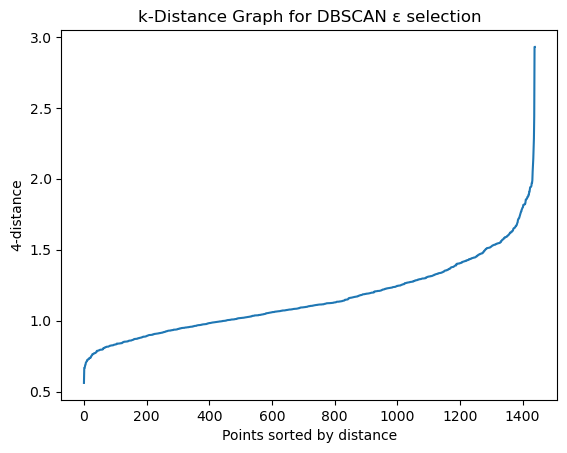

In [29]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# The 'elbow' on the k-distance plot approximates a natural density boundary in the data
# (Distinguishes cluster from noise)
def plot_k_distance(X, k):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, -1])
    plt.plot(k_distances)
    plt.ylabel(f"{k}‑distance")
    plt.xlabel("Points sorted by distance")
    plt.title("k‑Distance Graph for DBSCAN ε selection")
    plt.show()

# Rule of thumb: min_samples≈D+1 
# (So you dont cluster in a subspace and take advantage of all the dims available)
plot_k_distance(X_tsne, k=4)

In [30]:
# Train algorithm
dbscan = DBSCAN(eps=1.6, min_samples=4)
dbscan.fit(X_tsne)

# Evaluate
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y_labels, dbscan.labels_)
print(f"Adjusted Rand Index: {ari:.4f}")

DBSCAN: 100%|██████████| 1440/1440 [00:00<00:00, 40732.38it/s]

Adjusted Rand Index: 0.8668
